In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("../data/airline_passenger_satisfaction.csv")


In [4]:
features = [
    'Age',
    'Flight Distance',
    'Departure Delay',
    'Arrival Delay',
    'Satisfaction',
    'Class'
]


In [5]:
df = df[features].copy()

df['Satisfaction'] = df['Satisfaction'].astype(str).str.strip().str.lower()
df['Class'] = df['Class'].astype(str).str.strip().str.lower()

df['Satisfaction'] = df['Satisfaction'].map({
    'satisfied': 1,
    'neutral or dissatisfied': 0
})

df['Class'] = df['Class'].map({
    'eco': 0,
    'eco plus': 1,
    'business': 2
})


Missing Values:
 Age                0
Flight Distance    0
Departure Delay    0
Arrival Delay      0
Satisfaction       0
Class              0
dtype: int64


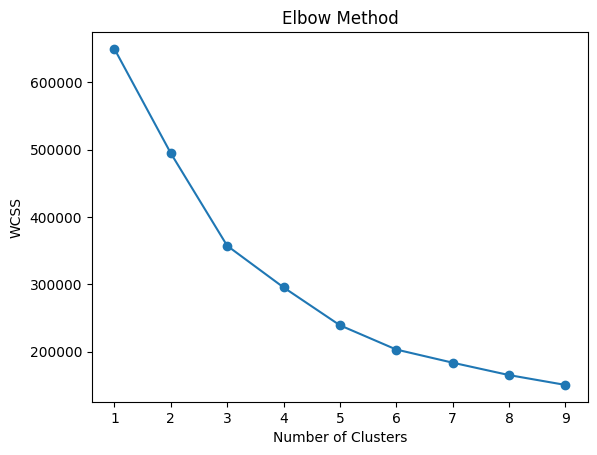

In [6]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# FINAL CHECK (must be zero)
print("Missing Values:\n", df.isnull().sum())

# ==============================
# 7. FEATURE SCALING
# ==============================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# ==============================
# 8. ELBOW METHOD
# ==============================
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



Cluster Summary:
                Age  Flight Distance  Departure Delay  Arrival Delay  \
Cluster                                                               
0        41.796857      1534.248614         7.269468       7.219375   
1        37.614827       922.521133         9.171784       9.780603   
2        38.922500      1170.861352       149.422586     151.025953   

         Satisfaction  Class  
Cluster                       
0            0.998183    2.0  
1            0.000000    2.0  
2            0.349685    2.0  


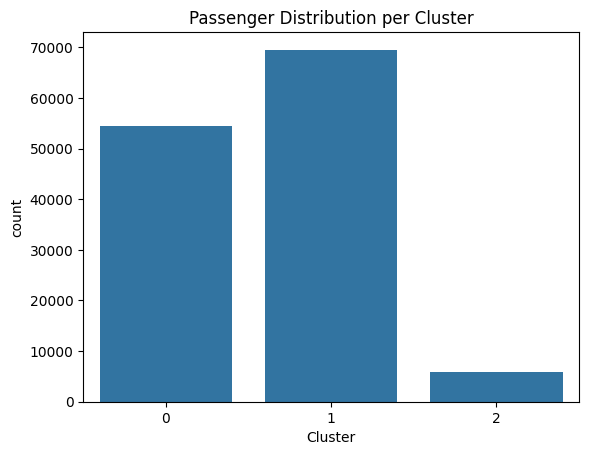


Generated Insights:

Cluster 0: High satisfaction, mostly business class passengers, experience low delays, prefer short-distance flights.

Cluster 1: Low satisfaction, mostly business class passengers, experience low delays, prefer short-distance flights.

Cluster 2: Low satisfaction, mostly business class passengers, experience high delays, prefer short-distance flights.


In [7]:
df_original=pd.read_csv("../data/airline_passenger_satisfaction.csv")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_original['Cluster'] = kmeans.fit_predict(scaled_data)
df['Cluster']=kmeans.fit_predict(scaled_data)

# ==============================
# 10. CLUSTER ANALYSIS
# ==============================
cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary:\n", cluster_summary)

# ==============================
# 11. VISUALIZATION
# ==============================
sns.countplot(x='Cluster', data=df)
plt.title("Passenger Distribution per Cluster")
plt.show()

# ==============================
# 12. AUTO INSIGHT GENERATION
# ==============================
def generate_insights(summary):
    insights = []

    for cluster in summary.index:
        row = summary.loc[cluster]

        text = f"\nCluster {cluster}: "

        # Satisfaction
        if row['Satisfaction'] > 0.6:
            text += "High satisfaction, "
        else:
            text += "Low satisfaction, "

        # Class
        if row['Class'] > 1.2:
            text += "mostly business class passengers, "
        elif row['Class'] > 0.5:
            text += "mid-range travelers, "
        else:
            text += "economy class passengers, "

        # Delay
        if row['Departure Delay'] > 20:
            text += "experience high delays, "
        else:
            text += "experience low delays, "

        # Distance
        if row['Flight Distance'] > 2000:
            text += "prefer long-distance flights."
        else:
            text += "prefer short-distance flights."

        insights.append(text)

    return insights

insights = generate_insights(cluster_summary)

print("\nGenerated Insights:")
for i in insights:
    print(i)

In [8]:
# ==============================
# 13. CORRELATION INSIGHTS
# ==============================
print("\nCorrelation Insights:")
corr = df.corr()

for col in corr.columns:
    if col != 'Satisfaction':
        val = corr['Satisfaction'][col]

        if val < -0.5:
            print(f"{col} has strong negative impact on satisfaction")
        elif val > 0.5:
            print(f"{col} has strong positive impact on satisfaction")



Correlation Insights:
Cluster has strong negative impact on satisfaction


In [9]:
# ==============================
# 14. PERCENTAGE-BASED INSIGHT
# ==============================
business_sat = df[df['Class'] == 2]['Satisfaction'].mean()
eco_sat = df[df['Class'] == 0]['Satisfaction'].mean()


In [10]:
df_original.to_csv("customer_segments.csv", index=False)


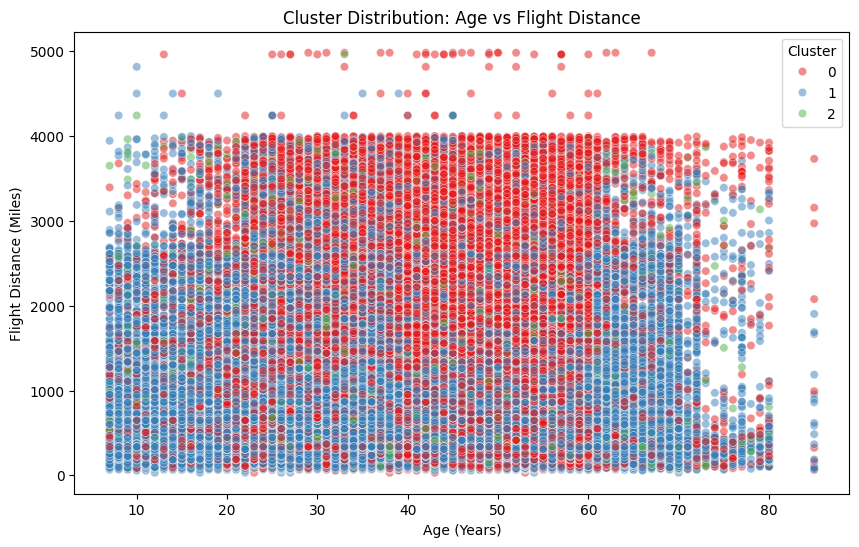

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Flight Distance', hue='Cluster', data=df, palette='Set1', alpha=0.5)
plt.title('Cluster Distribution: Age vs Flight Distance')
plt.xlabel('Age (Years)')
plt.ylabel('Flight Distance (Miles)')
plt.legend(title='Cluster')
plt.show()

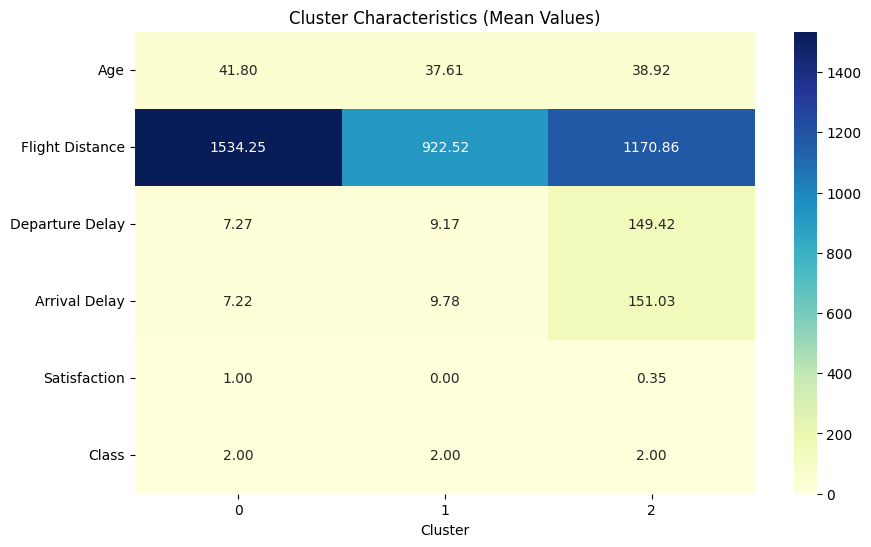

C:\Users\Tanishk\AppData\Local\Temp\ipykernel_11084\3104657149.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Flight Distance', data=df, ax=axes[0], palette='Set2')
C:\Users\Tanishk\AppData\Local\Temp\ipykernel_11084\3104657149.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Age', data=df, ax=axes[1], palette='Set2')
C:\Users\Tanishk\AppData\Local\Temp\ipykernel_11084\3104657149.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Departure Delay', data=df, ax=axes[2], palette='Set2'

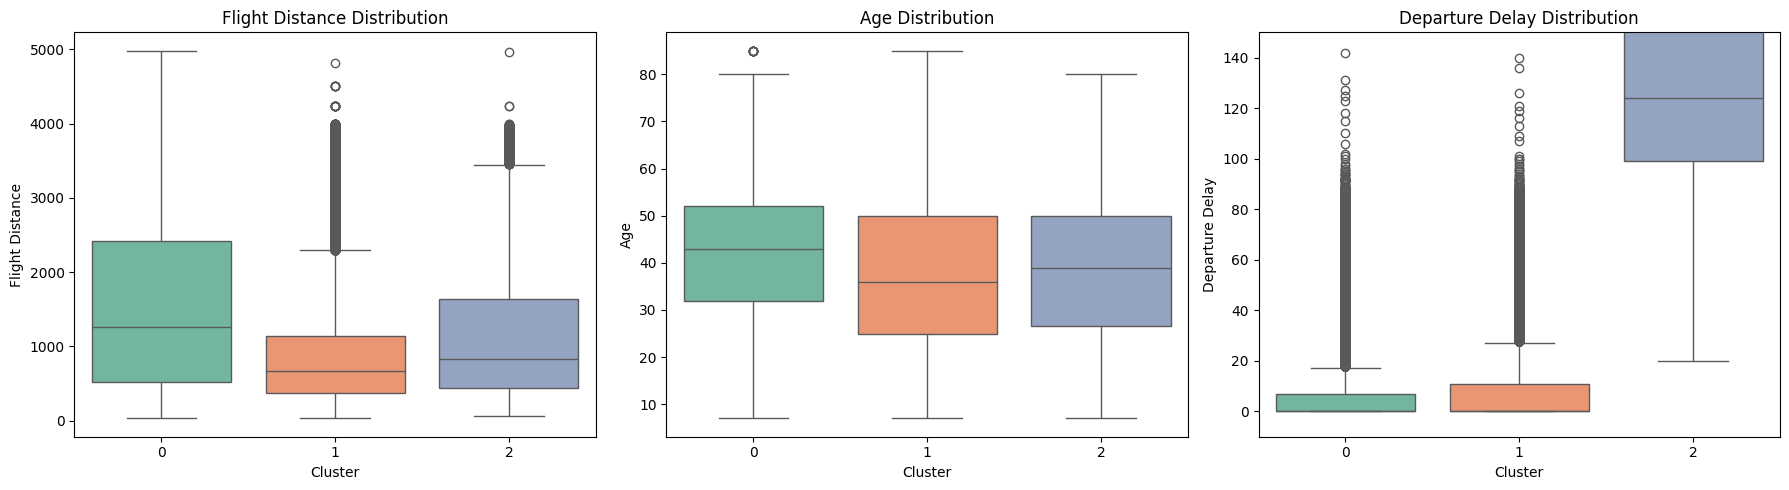

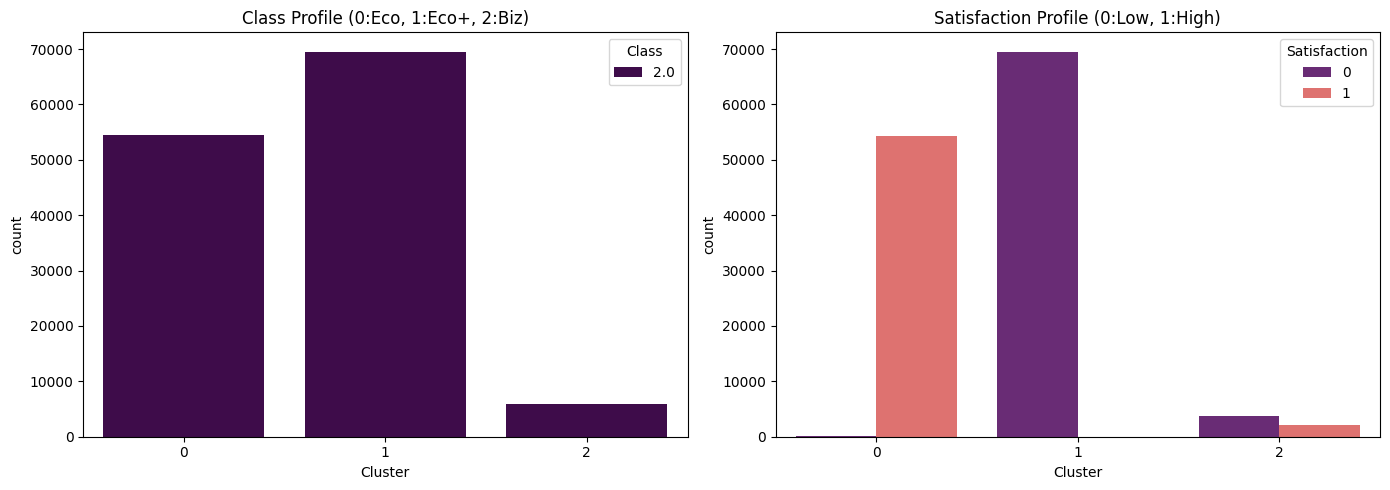

In [12]:
# ==============================
# 15. ADVANCED CLUSTER PROFILING PLOTS
# ==============================

# Plot 1: Heatmap of Cluster Centroids (Averages)
# This perfectly summarizes what distinguishes each cluster
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Characteristics (Mean Values)')
plt.show()

# Plot 2: Boxplots comparing distributions across clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(x='Cluster', y='Flight Distance', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Flight Distance Distribution')

sns.boxplot(x='Cluster', y='Age', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution')

sns.boxplot(x='Cluster', y='Departure Delay', data=df, ax=axes[2], palette='Set2')
axes[2].set_title('Departure Delay Distribution')
# Limiting y-axis on delay for better visibility as there are heavy outliers
axes[2].set_ylim(-10, 150) 
plt.tight_layout()
plt.show()

# Plot 3: Categorical composition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Cluster', hue='Class', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Class Profile (0:Eco, 1:Eco+, 2:Biz)')

sns.countplot(x='Cluster', hue='Satisfaction', data=df, ax=axes[1], palette='magma')
axes[1].set_title('Satisfaction Profile (0:Low, 1:High)')
plt.tight_layout()
plt.show()